# Week 9 & 10 — Model Evaluation and Feature Engineering
**Hack-O-Week | 5th Semester | SIT Nagpur**

1. Model evaluation: train/test split, cross-validation, confusion matrix, precision / recall / F1, ROC-AUC
2. Feature engineering & scaling, handling missing data

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, precision_score,
    recall_score, f1_score, accuracy_score, roc_curve, roc_auc_score, classification_report)
np.random.seed(0)
X,y = load_breast_cancer(return_X_y=True)

## Part A — Model Evaluation
### 1. Train/Test Split
Keep some data **hidden** during training (e.g. 75% train / 25% test) so we can check how the model behaves on *new* data. Use `stratify=y` so both parts have the same class ratio.

In [2]:
X_tr,X_te,y_tr,y_te = train_test_split(X,y,test_size=.25,random_state=42,stratify=y)
print("Train:",X_tr.shape,"Test:",X_te.shape)
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(X_tr,y_tr)
pred = model.predict(X_te); proba = model.predict_proba(X_te)[:,1]
print("Test accuracy:", round(accuracy_score(y_te,pred),3))

Train: (426, 30) Test: (143, 30)
Test accuracy: 0.986


### 2. Cross-Validation (k-fold)
One split can be lucky/unlucky. **k-fold CV:** split data into k parts; train on k−1 parts, test on the remaining one; repeat k times; average the scores. Gives a more reliable estimate.

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
print("Fold scores:", scores.round(3)); print("Mean = %.3f, Std = %.3f" % (scores.mean(), scores.std()))

Fold scores: [0.956 0.974 0.982 1.    0.982]
Mean = 0.979, Std = 0.014


### 3. Confusion Matrix
|  | Predicted Positive | Predicted Negative |
|---|---|---|
| **Actual Positive** | TP (correct) | FN (missed) |
| **Actual Negative** | FP (false alarm) | TN (correct) |

[[52  1]
 [ 1 89]]


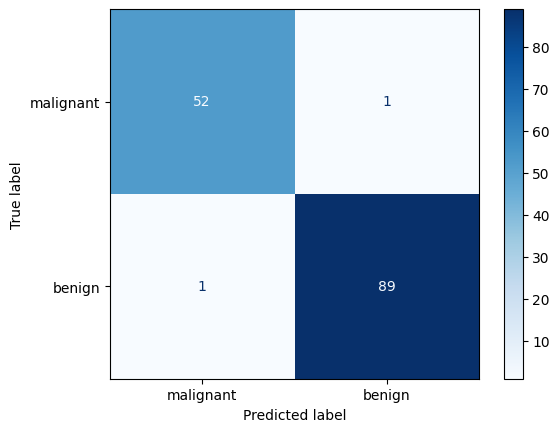

In [4]:
cm = confusion_matrix(y_te,pred); print(cm)
ConfusionMatrixDisplay(cm, display_labels=['malignant','benign']).plot(cmap='Blues'); plt.show()

### 4. Precision, Recall, F1
- **Precision** = TP / (TP + FP) → "Of all I called positive, how many were right?"
- **Recall** = TP / (TP + FN) → "Of all real positives, how many did I find?"
- **F1** = 2·P·R / (P + R) → balance of both (harmonic mean)
- **Accuracy** = (TP+TN) / total → misleading when classes are imbalanced.

*Example:* cancer screening → high **recall** matters (don't miss patients). Spam filter → high **precision** matters (don't hide real mail).

In [5]:
print("Precision:", round(precision_score(y_te,pred),3))
print("Recall   :", round(recall_score(y_te,pred),3))
print("F1-score :", round(f1_score(y_te,pred),3))
print("\n", classification_report(y_te,pred,target_names=['malignant','benign']))

# Why accuracy can fool you: a 'model' that always predicts the majority class on imbalanced data
y_imb = np.array([0]*95+[1]*5); dummy = np.zeros(100)
print("Imbalanced demo -> accuracy:", accuracy_score(y_imb,dummy), "but recall:", recall_score(y_imb,dummy))

Precision: 0.989
Recall   : 0.989
F1-score : 0.989

               precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        53
      benign       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143

Imbalanced demo -> accuracy: 0.95 but recall: 0.0


### 5. ROC Curve and AUC
Models output a probability. Changing the **threshold** changes results. ROC plots **TPR (recall)** vs **FPR** for all thresholds.
**AUC** = area under the curve. 1.0 = perfect, 0.5 = random guessing.

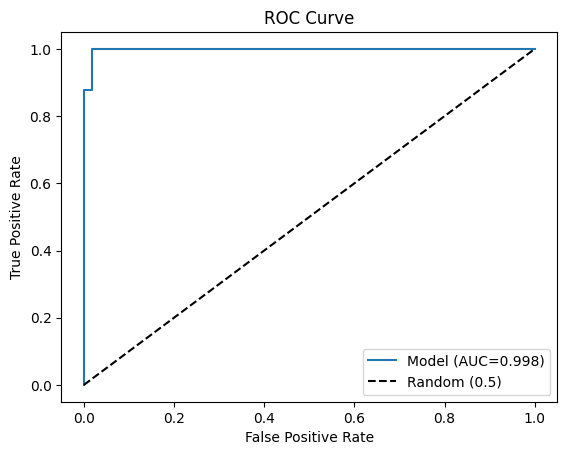

In [6]:
fpr,tpr,_ = roc_curve(y_te,proba); auc = roc_auc_score(y_te,proba)
plt.plot(fpr,tpr,label=f'Model (AUC={auc:.3f})'); plt.plot([0,1],[0,1],'k--',label='Random (0.5)')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('ROC Curve'); plt.legend(); plt.show()

## Part B — Feature Engineering, Scaling, Missing Data
### 6. Handling Missing Data
Options: (a) drop rows/columns, (b) **impute** — fill with mean / median / most-frequent, (c) add a "was missing" flag.
Rule: fit the imputer on **train data only** to avoid data leakage.

In [7]:
df = pd.DataFrame({
  'age':[25,32,np.nan,41,29,np.nan,50,38],
  'salary':[30000,42000,39000,np.nan,35000,41000,np.nan,52000],
  'city':['Nagpur','Pune','Nagpur',np.nan,'Mumbai','Pune','Nagpur','Pune'],
  'bought':[0,1,0,1,0,1,1,1]})
print(df.isna().sum(), "\n")
num = SimpleImputer(strategy='median').fit_transform(df[['age','salary']])
print("After median imputation:\n", pd.DataFrame(num,columns=['age','salary']))

age       2
salary    2
city      1
bought    0
dtype: int64 

After median imputation:
     age   salary
0  25.0  30000.0
1  32.0  42000.0
2  35.0  39000.0
3  41.0  40000.0
4  29.0  35000.0
5  35.0  41000.0
6  50.0  40000.0
7  38.0  52000.0


### 7. Feature Scaling
Features with different ranges (age 0-100 vs salary 0-1,00,000) confuse distance/gradient based models (KNN, SVM, Logistic, PCA).
- **StandardScaler (Z-score):** `(x − mean) / std` → mean 0, std 1
- **MinMaxScaler:** `(x − min) / (max − min)` → range 0 to 1
Tree models (Decision Tree, Random Forest) do **not** need scaling.

In [8]:
a = df[['age','salary']].fillna(df[['age','salary']].median())
print("StandardScaler:\n", pd.DataFrame(StandardScaler().fit_transform(a),columns=a.columns).round(2).head(4))
print("\nMinMaxScaler:\n", pd.DataFrame(MinMaxScaler().fit_transform(a),columns=a.columns).round(2).head(4))

StandardScaler:
     age  salary
0 -1.48   -1.68
1 -0.51    0.36
2 -0.09   -0.15
3  0.75    0.02

MinMaxScaler:
     age  salary
0  0.00    0.00
1  0.28    0.55
2  0.40    0.41
3  0.64    0.45


### 8. Feature Engineering
Creating better inputs from raw data: **encoding** categories (One-Hot), **new features** (ratios, date parts), **binning**, **log-transform** for skewed data, **interaction terms**.
Below we combine everything in one clean **Pipeline** (best practice; prevents leakage).

In [9]:
df['salary_per_year_of_age'] = df['salary']/df['age']          # engineered feature
num_cols = ['age','salary','salary_per_year_of_age']; cat_cols=['city']
prep = ColumnTransformer([
  ('num', Pipeline([('imp',SimpleImputer(strategy='median')),('sc',StandardScaler())]), num_cols),
  ('cat', Pipeline([('imp',SimpleImputer(strategy='most_frequent')),('oh',OneHotEncoder(handle_unknown='ignore'))]), cat_cols)])
pipe = Pipeline([('prep',prep),('clf',LogisticRegression())]).fit(df.drop(columns='bought'), df['bought'])
print("Pipeline trained. Output feature names:\n", list(prep.get_feature_names_out()))
print("Train accuracy:", pipe.score(df.drop(columns='bought'), df['bought']))

Pipeline trained. Output feature names:
 ['num__age', 'num__salary', 'num__salary_per_year_of_age', 'cat__city_Mumbai', 'cat__city_Nagpur', 'cat__city_Pune']
Train accuracy: 0.875


## Summary
| Concept | Remember |
|---|---|
| Train/Test split | Hold out unseen data (use stratify) |
| Cross-validation | Average of k folds = reliable score |
| Confusion matrix | TP, FP, FN, TN |
| Precision / Recall / F1 | Correctness / Coverage / Balance |
| ROC-AUC | Threshold-free quality; 0.5 random, 1 perfect |
| Missing data | Impute (fit on train only) |
| Scaling | Standard (z-score) or MinMax; needed for distance-based models |
| Feature engineering | Encode, create, transform features; wrap in Pipeline |